# 02 - Visualizations

This notebook focuses on charts for understanding distributions, relationships, and outliers.

In [4]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

data_path = Path(r"C:\Users\User\Desktop\house-price-prediction\data\processed\modeling_dataset.csv")

if not data_path.exists():
    raise FileNotFoundError(f"File not found: {data_path}")

df = pd.read_csv(data_path)


print("Shape:", df.shape)
df.head()

Shape: (167888, 70)


,parcelid,logerror,transactiondate,data_year,airconditioningtypeid,architecturalstyletypeid,basementsqft,bathroomcnt,bedroomcnt,buildingclasstypeid,...,censustractandblock,transaction_year,transaction_month,transaction_quarter,property_age,bath_bed_ratio,avg_room_size,structure_tax_ratio,land_tax_ratio,effective_tax_rate
0,11016594,0.0276,2016-01-01,2016,1.0,NaN,NaN,2.0,3.0,NaN,...,6.037107e+13,2016,1,1,57.0,0.666667,NaN,0.340822,0.659178,0.018702
1,14366692,-0.1684,2016-01-01,2016,NaN,NaN,NaN,3.5,4.0,NaN,...,NaN,2016,1,1,2.0,0.875000,NaN,0.591701,0.408299,0.017340
2,12098116,-0.0040,2016-01-01,2016,1.0,NaN,NaN,3.0,2.0,NaN,...,6.037464e+13,2016,1,1,76.0,1.500000,NaN,0.517022,0.482978,0.095779
3,12643413,0.0218,2016-01-02,2016,1.0,NaN,NaN,2.0,2.0,NaN,...,6.037296e+13,2016,1,1,29.0,1.000000,NaN,0.700417,0.299583,0.012450
4,14432541,-0.0050,2016-01-02,2016,NaN,NaN,NaN,2.5,4.0,NaN,...,6.059042e+13,2016,1,1,35.0,0.625000,285.375,0.390228,0.609772,0.012631


## Top numerical distributions

In [5]:
num_cols = df.select_dtypes(include=[np.number]).columns.tolist()
top_num_cols = [c for c in ["logerror","calculatedfinishedsquarefeet","lotsizesquarefeet","taxvaluedollarcnt","structuretaxvaluedollarcnt","landtaxvaluedollarcnt","bathroomcnt","bedroomcnt","yearbuilt"] if c in df.columns]
top_num_cols

['logerror',
 'calculatedfinishedsquarefeet',
 'lotsizesquarefeet',
 'taxvaluedollarcnt',
 'structuretaxvaluedollarcnt',
 'landtaxvaluedollarcnt',
 'bathroomcnt',
 'bedroomcnt',
 'yearbuilt']

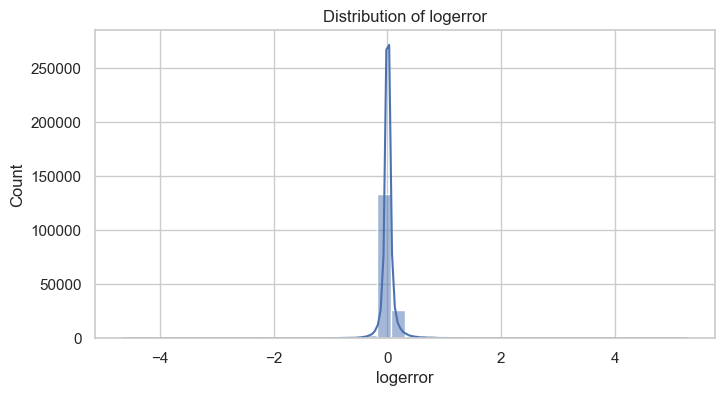

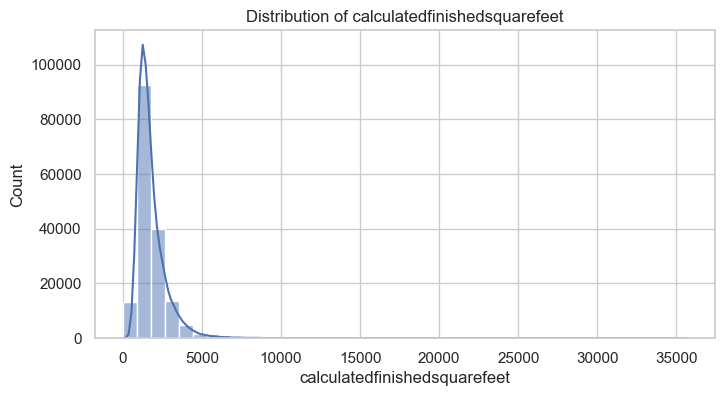

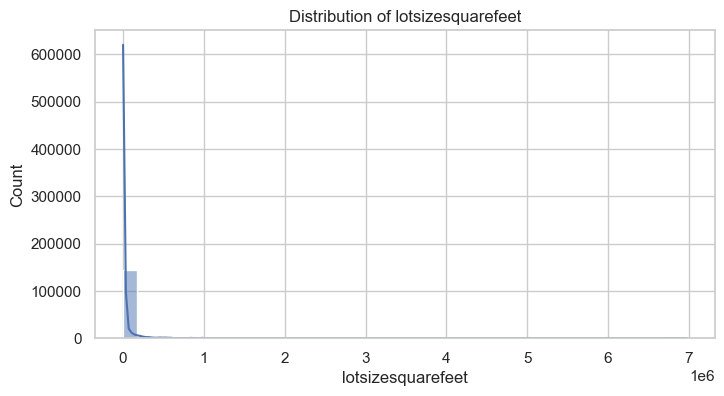

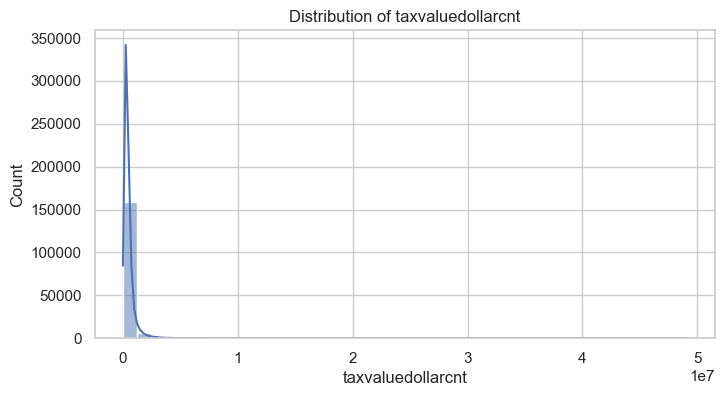

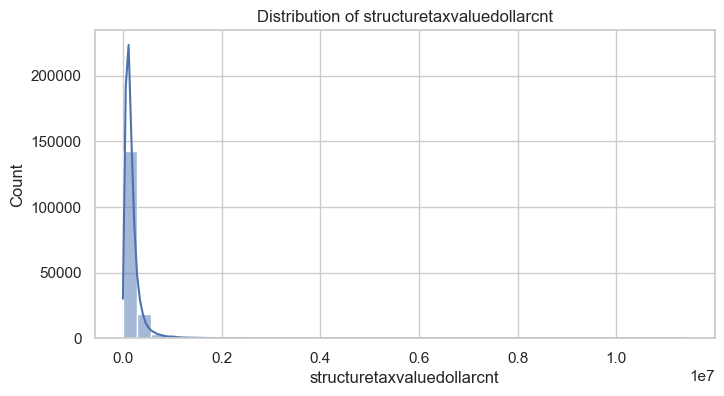

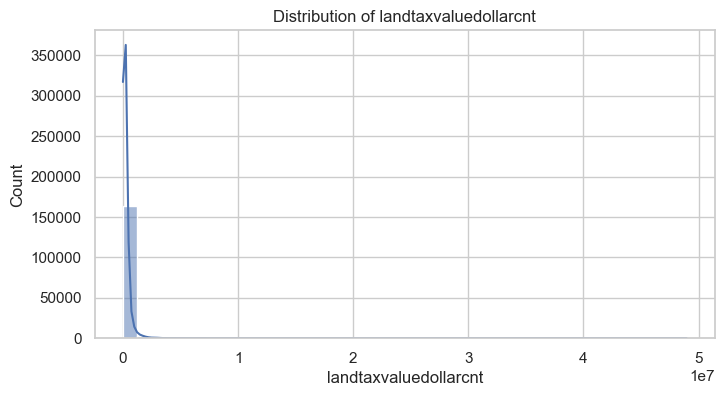

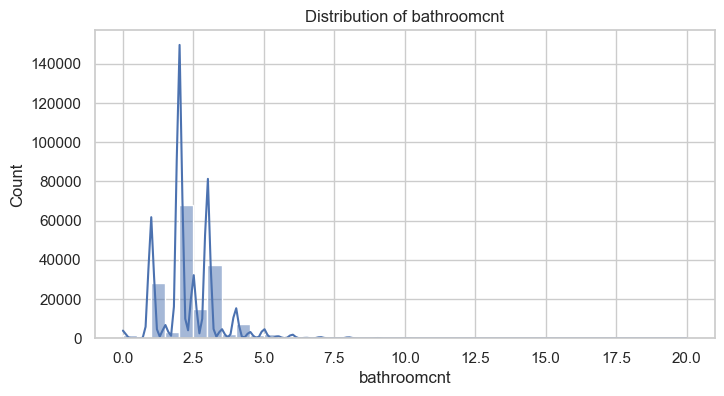

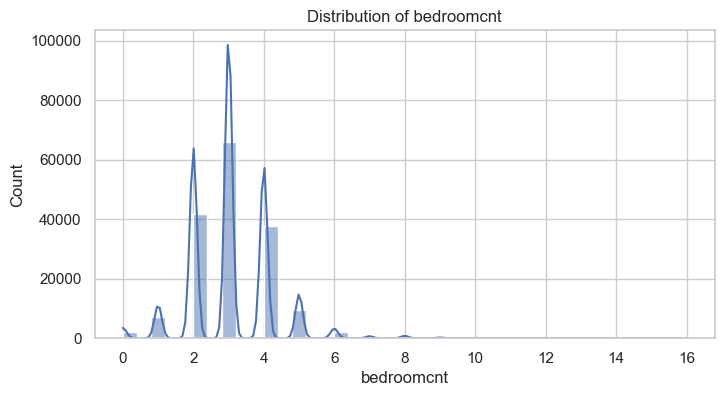

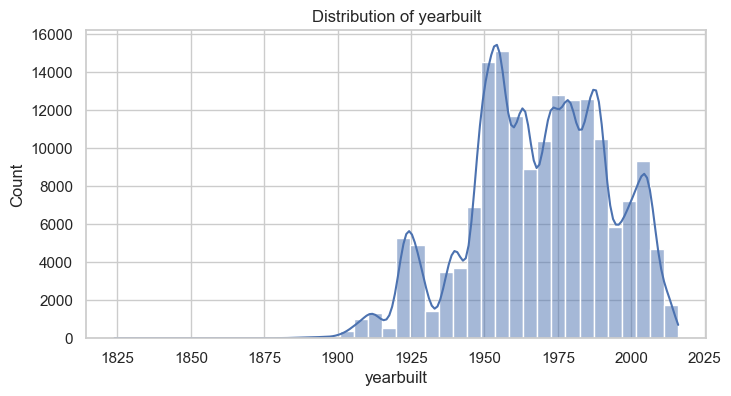

In [6]:
for col in top_num_cols:
    plt.figure(figsize=(8,4))
    sns.histplot(df[col].dropna(), bins=40, kde=True)
    plt.title(f"Distribution of {col}")
    plt.show()

## Outlier inspection with boxplots

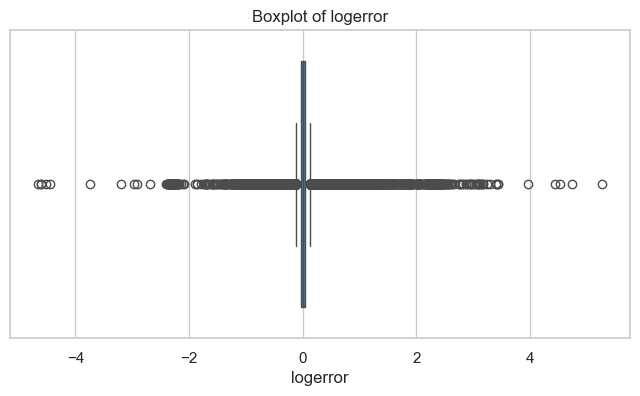

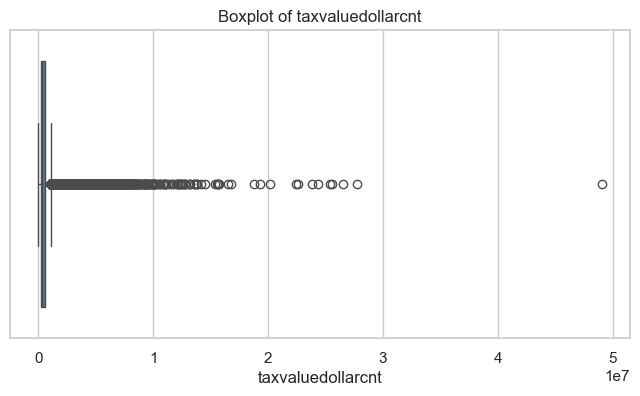

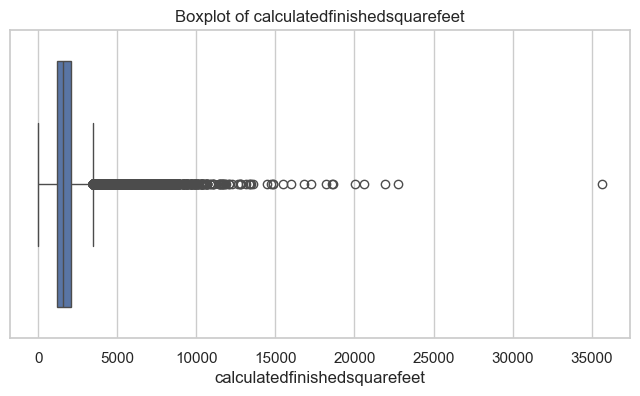

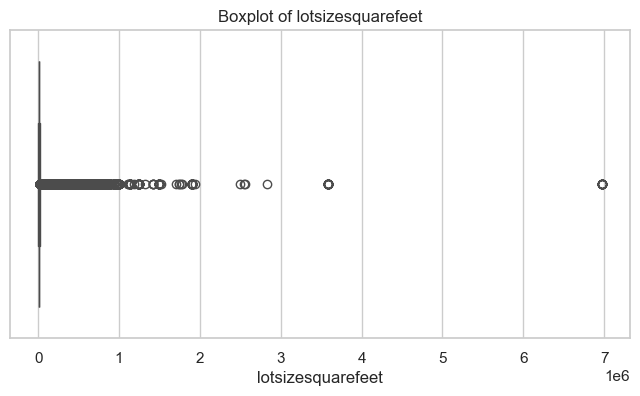

In [7]:
for col in [c for c in ["logerror","taxvaluedollarcnt","calculatedfinishedsquarefeet","lotsizesquarefeet"] if c in df.columns]:
    plt.figure(figsize=(8,4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot of {col}")
    plt.show()

## Scatterplots against target

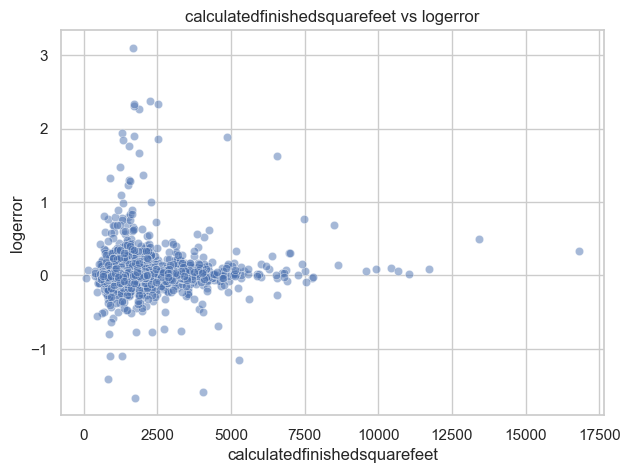

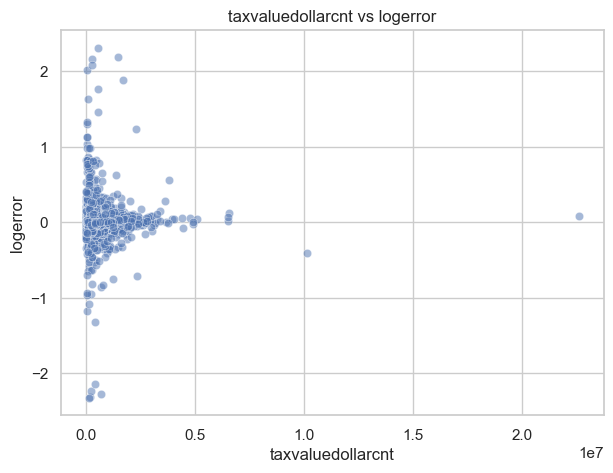

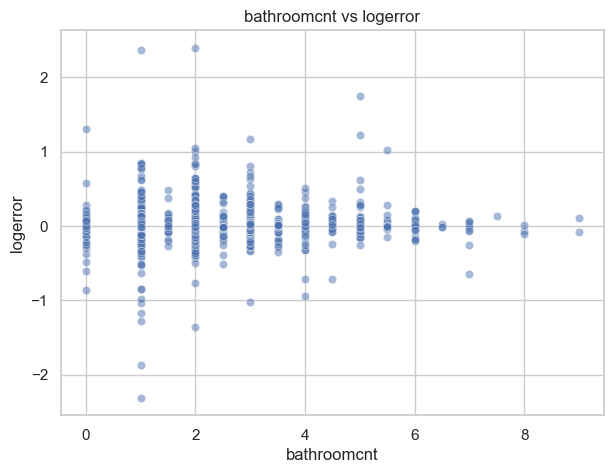

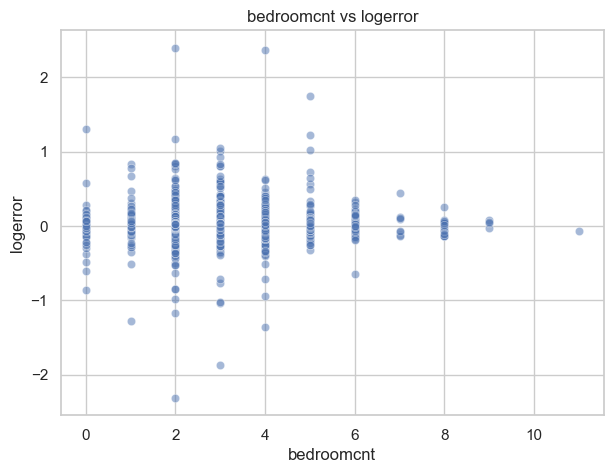

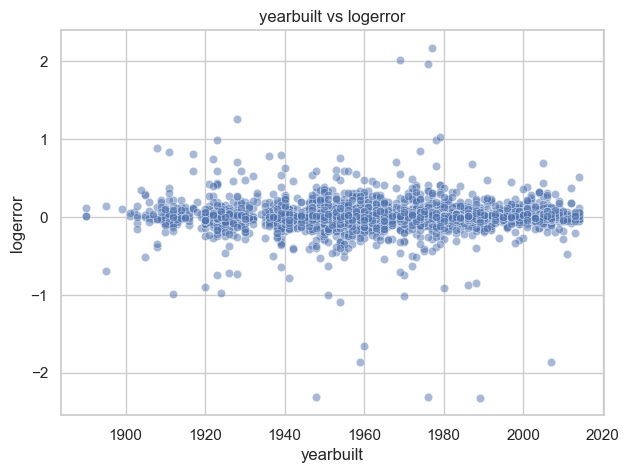

In [8]:
if "logerror" in df.columns:
    for col in [c for c in ["calculatedfinishedsquarefeet","taxvaluedollarcnt","bathroomcnt","bedroomcnt","yearbuilt"] if c in df.columns]:
        temp = df[[col, "logerror"]].dropna()
        if len(temp) > 0:
            sample_df = temp.sample(min(5000, len(temp)), random_state=42)
            plt.figure(figsize=(7,5))
            sns.scatterplot(data=sample_df, x=col, y="logerror", alpha=0.5)
            plt.title(f"{col} vs logerror")
            plt.show()
else:
    print("Target column 'logerror' not found.")

## Correlation heatmap

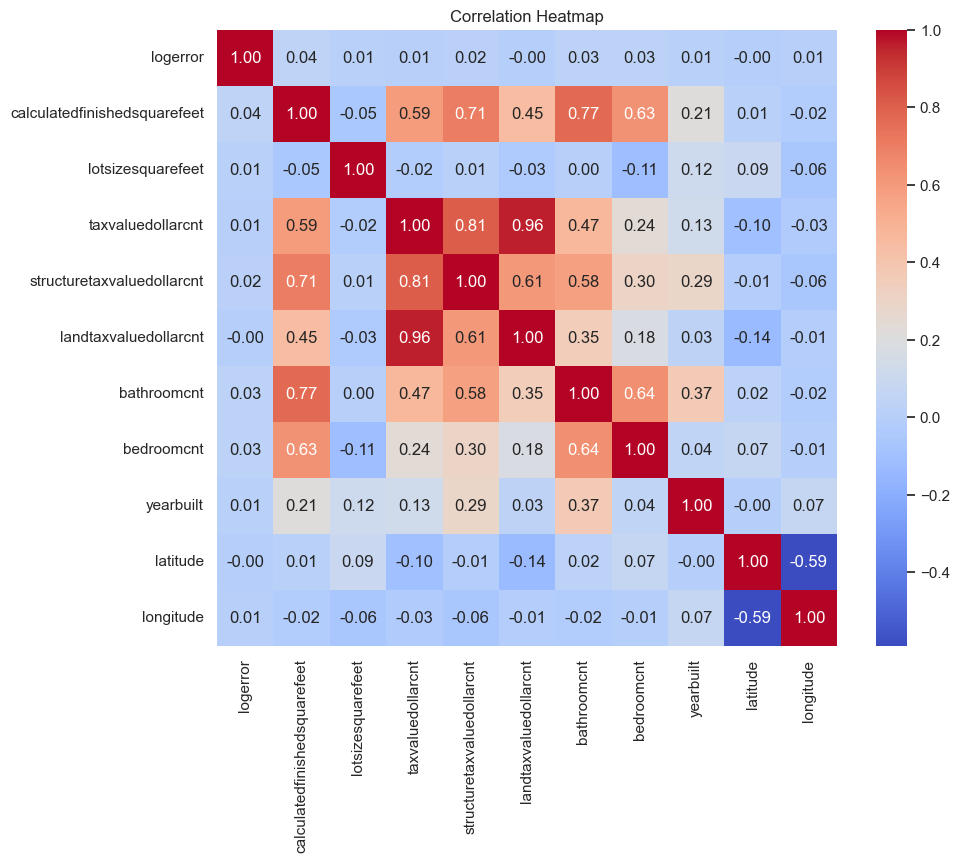

In [9]:
num_df = df.select_dtypes(include=[np.number]).copy()
corr_cols = [c for c in ["logerror","calculatedfinishedsquarefeet","lotsizesquarefeet","taxvaluedollarcnt","structuretaxvaluedollarcnt","landtaxvaluedollarcnt","bathroomcnt","bedroomcnt","yearbuilt","latitude","longitude"] if c in num_df.columns]
if len(corr_cols) > 1:
    corr = num_df[corr_cols].corr()
    plt.figure(figsize=(10,8))
    sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f")
    plt.title("Correlation Heatmap")
    plt.show()